In [27]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import fsolve

In [28]:
# Parameters

asset = "MSFT"  # Microsoft
ticker = yf.Ticker(asset)                          
S0 = ticker.history(period="1d")["Close"].iloc[-1]  # Spot price in $
sigma0 = 0.6    # volatility
r= 0.03         # interest rate
q = 0           # dividend yield
print(S0)

498.0


In [29]:
expiries = ticker.options  # available maturity for the options
expiries
expiries = list(expiries)
expiries

['2026-09-23',
 '2026-09-25',
 '2026-09-28',
 '2026-09-30',
 '2026-10-02',
 '2026-10-05',
 '2026-10-09',
 '2026-10-16',
 '2026-10-23',
 '2026-10-30',
 '2026-11-20',
 '2026-12-18',
 '2027-01-15',
 '2027-03-19',
 '2027-04-16',
 '2027-06-17',
 '2027-09-17',
 '2027-12-17',
 '2028-01-21',
 '2028-06-16',
 '2028-12-15',
 '2029-01-19']

In [30]:
# For each maturity date, we add a price, strike for a call option and put option

L_call = []
L_put = []

for maturity in expiries:

    option_chain = ticker.option_chain(date=maturity)

    call = option_chain.calls
    call["Maturity"] = maturity
    L_call.append(call)

    put = option_chain.puts
    put["Maturity"] = maturity
    L_put.append(put)

df_call= pd.concat(L_call)
df_put = pd.concat(L_put)
df_call


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,Maturity
0,MSFT260923C00430000,2026-09-22 16:00:03+00:00,430.0,64.52,0.0,0.0,0.0,0.0,14.0,0.0,0.000010,True,REGULAR,USD,2026-09-23
1,MSFT260923C00435000,2026-09-22 16:00:03+00:00,435.0,59.57,NaN,NaN,0.0,0.0,NaN,NaN,0.000000,True,REGULAR,USD,2026-09-23
2,MSFT260923C00440000,2026-09-22 16:09:10+00:00,440.0,55.27,0.0,0.0,0.0,0.0,29.0,0.0,0.000010,True,REGULAR,USD,2026-09-23
3,MSFT260923C00442500,2026-09-22 16:09:10+00:00,442.5,52.82,NaN,NaN,0.0,0.0,NaN,NaN,0.000000,True,REGULAR,USD,2026-09-23
4,MSFT260923C00445000,2026-09-22 18:47:08+00:00,445.0,54.00,0.0,0.0,0.0,0.0,24.0,0.0,0.000010,True,REGULAR,USD,2026-09-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,MSFT290119C00710000,2026-09-18 13:42:13+00:00,710.0,51.00,0.0,0.0,0.0,0.0,1.0,0.0,0.031260,False,REGULAR,USD,2029-01-19
59,MSFT290119C00720000,2026-09-16 13:47:41+00:00,720.0,48.96,0.0,0.0,0.0,0.0,NaN,0.0,0.062509,False,REGULAR,USD,2029-01-19
60,MSFT290119C00730000,2026-09-22 19:02:06+00:00,730.0,48.45,0.0,0.0,0.0,0.0,4.0,0.0,0.062509,False,REGULAR,USD,2029-01-19
61,MSFT290119C00740000,2026-09-16 16:48:50+00:00,740.0,45.51,0.0,0.0,0.0,0.0,NaN,0.0,0.062509,False,REGULAR,USD,2029-01-19


In [31]:
# Building the dataframes and first cleaning

columns = ["strike",'Maturity',"lastPrice","bid","ask","impliedVolatility","volume"]



df_call = df_call[columns]

df_call["mid"] = 0.5 * (df_call["bid"] + df_call["ask"])

df_call["Maturity"] = pd.to_datetime(df_call["Maturity"])

# filter

# Strike between 80% et 120%
strike_filter = (S0*0.8< df_call["strike"]) & (df_call["strike"]<S0*1.2)
df_call = df_call[strike_filter]

# maturity between today and 3 months 
maturity_filter = (df_call["Maturity"]>pd.Timestamp.today()) & (df_call["Maturity"] < pd.Timestamp.today() + pd.Timedelta(days=100))
df_call = df_call[maturity_filter]

# volume > 50
df_call = df_call[df_call["volume"]>50]

#mid price
# mid_filter = (df_call["mid"] >= 0.10)
# df_call = df_call[mid_filter]

df_call

# Put filter

df_put = df_put[columns]
df_put["mid"] = 0.5 * (df_put["bid"] + df_put["ask"])
df_put["Maturity"] = pd.to_datetime(df_put["Maturity"])



strike_filter = (S0*0.8< df_put["strike"]) & (df_put["strike"]<S0*1.2)
df_put = df_put[strike_filter]

maturity_filter = (df_put["Maturity"]>pd.Timestamp.today()) & (df_put["Maturity"] < pd.Timestamp.today() + pd.Timedelta(days=100))
df_put = df_put[maturity_filter]

# volume > 50
df_put = df_put[df_put["volume"]>50]

# mid price
mid_filter = (df_put["mid"] >= 0.10)
df_put = df_put[mid_filter]

df_call


C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\31573668.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_call["mid"] = 0.5 * (df_call["bid"] + df_call["ask"])
C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\31573668.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_call["Maturity"] = pd.to_datetime(df_call["Maturity"])


,strike,Maturity,lastPrice,bid,ask,impliedVolatility,volume,mid
28,442.5,2026-09-25,53.02,0.0,0.0,0.000010,56.0,0.0
36,462.5,2026-09-25,37.20,0.0,0.0,0.000010,103.0,0.0
39,470.0,2026-09-25,28.60,0.0,0.0,0.000010,136.0,0.0
40,472.5,2026-09-25,26.03,0.0,0.0,0.000010,140.0,0.0
41,475.0,2026-09-25,24.49,0.0,0.0,0.000010,68.0,0.0
...,...,...,...,...,...,...,...,...
77,560.0,2026-12-18,9.98,0.0,0.0,0.062509,118.0,0.0
78,565.0,2026-12-18,8.80,0.0,0.0,0.062509,66.0,0.0
79,570.0,2026-12-18,7.91,0.0,0.0,0.062509,90.0,0.0
80,575.0,2026-12-18,7.15,0.0,0.0,0.062509,118.0,0.0


In [32]:
# Price Call/Put with Black and Scholes
def black_scholes(S0,K,r,sigma,T,q,option_type="call"):

    d1= (np.log(S0/K)+(0.5*sigma**2*+r-q)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        return S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2) 
    
    if option_type == "put":
        return K*np.exp(-r*T)*norm.cdf(-d2)-S0*norm.cdf(-d1) 

In [33]:
option_type = "call"

In [34]:
# Function to get the determine the implied volatility
def implied_volatility(S0,K,T,r,q,market_price):
    def f(sigma):
        return black_scholes(S0,K,r,sigma,T,q,option_type)-market_price
    return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)  

In [35]:
# For a given maturity date, we want to know the value of the implied volatility for each strike

smile = {}

for t in df_call["Maturity"].drop_duplicates():
    time_to_maturity = (t - pd.Timestamp.today()).days / 365
    L_implied_vol=[]
    L_K = []

    df_t = df_call[df_call["Maturity"]==t]

    for _,row in df_t.iterrows():
        K = row["strike"]
        market_price = row["lastPrice"]     # or  row["mid"] 

        implied_vol = float(implied_volatility(S0,K,time_to_maturity,r,q,market_price)[0])
        L_implied_vol.append(implied_vol)
        L_K.append(K)
    
    smile[t] = {"K":L_K,
                "iv":L_implied_vol}
        

C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)


In [36]:
smile

{Timestamp('2026-09-25 00:00:00'): {'K': [442.5,
   462.5,
   470.0,
   472.5,
   475.0,
   480.0,
   485.0,
   487.5,
   490.0,
   492.5,
   495.0,
   497.5,
   500.0,
   502.5,
   505.0,
   507.5,
   510.0,
   512.5,
   515.0,
   517.5,
   520.0,
   522.5,
   525.0,
   527.5,
   530.0,
   532.5,
   535.0,
   540.0,
   547.5,
   550.0,
   555.0,
   565.0],
  'iv': [0.030717207456724904,
   1.1795924521951389,
   0.7424038995469776,
   0.6682921769560035,
   0.8254443024916159,
   0.664711036981231,
   0.5828168843748939,
   0.5599262192484152,
   0.5561533763823522,
   0.5623881064697621,
   0.49955522631768046,
   0.4979946240374007,
   0.486597161218758,
   0.4905852360881012,
   0.49063056722621673,
   0.4863568998786413,
   0.4901727235260607,
   0.4950527058410096,
   0.5000164032753882,
   0.5076719706612932,
   0.5122218220418883,
   0.5251939330257387,
   0.5374746961424797,
   0.5524179589514256,
   0.5672456456112048,
   0.6034848279460715,
   0.6084732802002477,
   0.647982

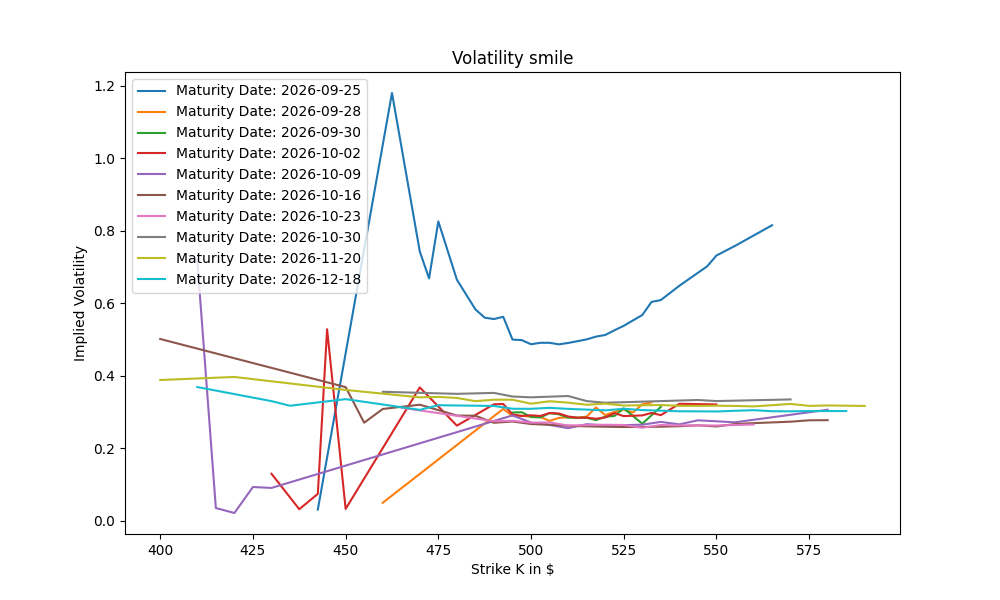

In [37]:
plt.figure(figsize=(10,6))
for t, data in smile.items():  # smile.items() renvoie couples (clé,valeur)
    plt.plot(data["K"],data["iv"],label="Maturity Date: " + str(t.date()))

plt.xlabel("Strike K in $")
plt.ylabel("Implied Volatility")
plt.title('Volatility smile')
plt.legend()
plt.show()

In [38]:
# For a given strike, we want to know the value of the implied volatility for each maturity

term_structure = {}
df_call = df_call.sort_values(by="strike",ascending=True)
for K in df_call["strike"].drop_duplicates():
    L_implied_vol=[]
    L_T = []

    df_K = df_call[df_call["strike"]==K]

    for _,row in df_K.iterrows():
        T = row["Maturity"]
        time_to_maturity = (T - pd.Timestamp.today()).days / 365
        market_price = row["lastPrice"]  # or row["mid"]

        implied_vol = float(implied_volatility(S0,K,time_to_maturity,r,q,market_price)[0])  # [0]
        
        L_implied_vol.append(implied_vol)
        #implied_vol = row["impliedVolatility"]
        L_T.append(T)
    
    term_structure[K] = {"T":L_T,
                "iv":L_implied_vol}
print(term_structure)

C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_20368\1464899031.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  return fsolve(f,x0=sigma0,xtol=1e-8,maxfev=500)
C:\Users\antoi\AppData\Local\Temp\ipykernel_

{400.0: {'T': [Timestamp('2026-10-16 00:00:00'), Timestamp('2026-11-20 00:00:00')], 'iv': [0.5011574009916138, 0.3880067131107079]}, 410.0: {'T': [Timestamp('2026-12-18 00:00:00'), Timestamp('2026-10-09 00:00:00')], 'iv': [0.3686183181878667, 0.7175978638542937]}, 415.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.03494271326002962]}, 420.0: {'T': [Timestamp('2026-11-20 00:00:00'), Timestamp('2026-10-09 00:00:00')], 'iv': [0.396400513564611, 0.02120672482138261]}, 425.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.09287918368533207]}, 430.0: {'T': [Timestamp('2026-12-18 00:00:00'), Timestamp('2026-10-02 00:00:00'), Timestamp('2026-10-09 00:00:00')], 'iv': [0.3297543532277469, 0.129452822762996, 0.09036728320121923]}, 435.0: {'T': [Timestamp('2026-12-18 00:00:00')], 'iv': [0.3170070497874734]}, 437.5: {'T': [Timestamp('2026-10-02 00:00:00')], 'iv': [0.03167426343430482]}, 442.5: {'T': [Timestamp('2026-09-25 00:00:00'), Timestamp('2026-10-02 00:00:00')], 'iv': [0.0307172074

In [39]:
term_structure

{400.0: {'T': [Timestamp('2026-10-16 00:00:00'),
   Timestamp('2026-11-20 00:00:00')],
  'iv': [0.5011574009916138, 0.3880067131107079]},
 410.0: {'T': [Timestamp('2026-12-18 00:00:00'),
   Timestamp('2026-10-09 00:00:00')],
  'iv': [0.3686183181878667, 0.7175978638542937]},
 415.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.03494271326002962]},
 420.0: {'T': [Timestamp('2026-11-20 00:00:00'),
   Timestamp('2026-10-09 00:00:00')],
  'iv': [0.396400513564611, 0.02120672482138261]},
 425.0: {'T': [Timestamp('2026-10-09 00:00:00')], 'iv': [0.09287918368533207]},
 430.0: {'T': [Timestamp('2026-12-18 00:00:00'),
   Timestamp('2026-10-02 00:00:00'),
   Timestamp('2026-10-09 00:00:00')],
  'iv': [0.3297543532277469, 0.129452822762996, 0.09036728320121923]},
 435.0: {'T': [Timestamp('2026-12-18 00:00:00')], 'iv': [0.3170070497874734]},
 437.5: {'T': [Timestamp('2026-10-02 00:00:00')], 'iv': [0.03167426343430482]},
 442.5: {'T': [Timestamp('2026-09-25 00:00:00'),
   Timestamp('2026-10-0

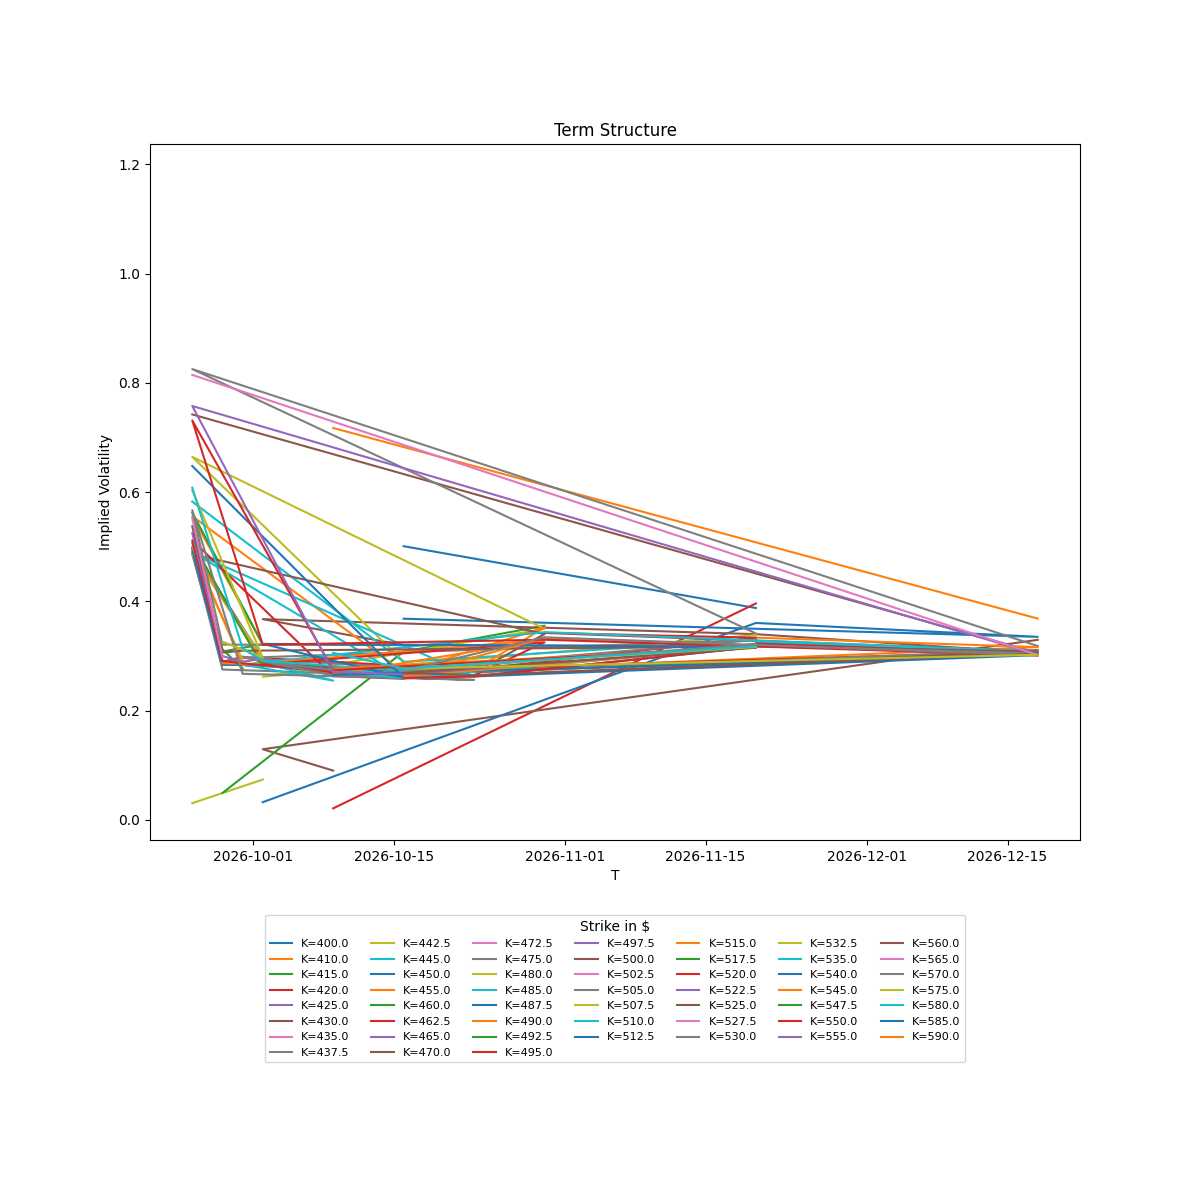

In [40]:
plt.figure(figsize=(12,12))
Ks_to_plot = np.arange(360,450,10) #[360.0, 370 ,380.0,390,400,410]
for K, data in term_structure.items():  # term_structure.items() renvoie couples (clé,valeur)
    plt.plot(data["T"],data["iv"],label=f"K={K}")

plt.xlabel("T")
plt.ylabel("Implied Volatility")
plt.title('Term Structure')

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=7,           
    title="Strike in $",
    fontsize=8,
    frameon=True
)

plt.subplots_adjust(bottom=0.30)

plt.show()

In [41]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------
# 1. Transformer smile en trois vecteurs : K, T, IV
# ------------------------------------------------------

valuation_date = pd.Timestamp.today().normalize()

K_obs = []
T_obs = []
IV_obs = []

for maturity, values in smile.items():

    # Conversion de la date d'échéance en temps à maturité en années
    T = (
        pd.Timestamp(maturity) - valuation_date
    ).total_seconds() / (365.25 * 24 * 3600)

    # Éviter les options déjà expirées
    if T <= 0:
        continue

    for K, iv in zip(values["K"], values["iv"]):

        # Garde-fous : IV positive, finie et non aberrante
        if np.isfinite(iv) and 0.01 < iv < 1.50:
            K_obs.append(float(K))
            T_obs.append(float(T))
            IV_obs.append(float(iv))

K_obs = np.array(K_obs)
T_obs = np.array(T_obs)
IV_obs = np.array(IV_obs)

print("Nombre de points :", len(IV_obs))
print("Nombre de maturités :", len(np.unique(T_obs)))
print("Nombre de strikes :", len(np.unique(K_obs)))

Nombre de points : 208
Nombre de maturités : 10
Nombre de strikes : 52


In [42]:
# ------------------------------------------------------
# 2. Créer une grille régulière (K, T)
# ------------------------------------------------------

K_grid = np.linspace(K_obs.min(), K_obs.max(), 80)
T_grid = np.linspace(T_obs.min(), T_obs.max(), 80)

K_mesh, T_mesh = np.meshgrid(K_grid, T_grid)

# Interpolation linéaire dans la zone où les données existent
IV_mesh = griddata(
    points=(K_obs, T_obs),
    values=IV_obs,
    xi=(K_mesh, T_mesh),
    method="linear"
)

# griddata(linear) laisse des NaN aux bords :
# ce remplissage est seulement pour afficher une surface complète.
IV_nearest = griddata(
    points=(K_obs, T_obs),
    values=IV_obs,
    xi=(K_mesh, T_mesh),
    method="nearest"
)

IV_mesh_plot = np.where(
    np.isnan(IV_mesh),
    IV_nearest,
    IV_mesh
)

In [43]:
# For 3D view
%matplotlib widget

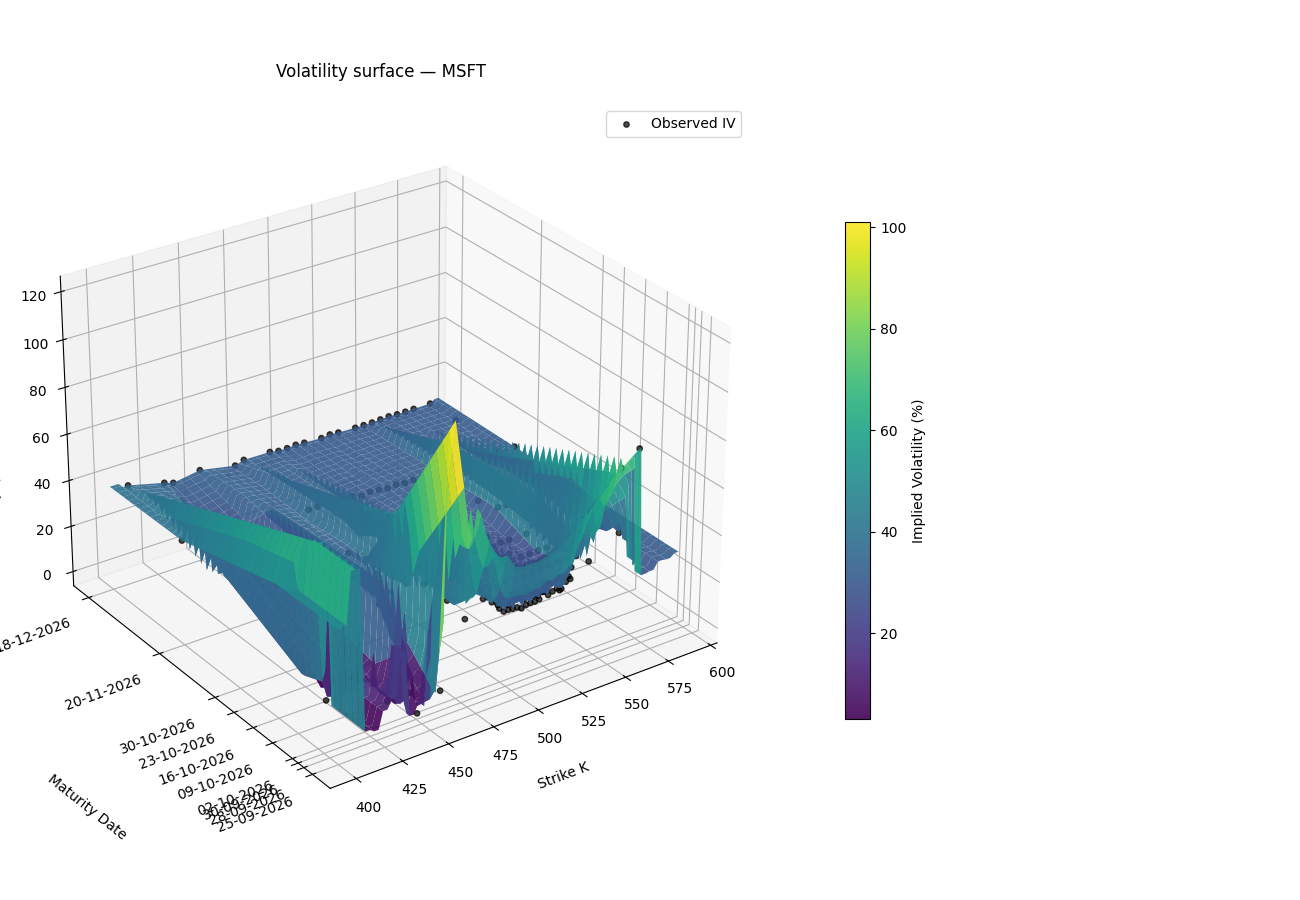

In [44]:
# ------------------------------------------------------
# 3. Tracé de la surface de volatilité implicite
# ------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Important :
# valuation_date doit être exactement la même date que celle
# utilisée pour construire T_obs, T_mesh et df_surface["T"].
valuation_date = pd.Timestamp.today().normalize()

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection="3d")


# Surface interpolée
surf = ax.plot_surface(
    K_mesh,                 # axe x : strike
    T_mesh,                 # axe y : temps à maturité en années
    100 * IV_mesh_plot,     # axe z : IV affichée en %
    cmap="viridis",
    edgecolor="none",
    alpha=0.90,
    antialiased=True
)


# Points d'IV réellement observés
ax.scatter(
    K_obs,
    T_obs,
    100 * IV_obs,
    color="black",
    s=15,
    alpha=0.70,
    label="Observed IV"
)


# Labels x et z
ax.set_xlabel("Strike K", labelpad=12)
ax.set_zlabel("Implied Volatility (%)", labelpad=12)


# ------------------------------------------------------
# Dates sur l'axe des maturités y
# ------------------------------------------------------

# Utilise df_call si c'est le DataFrame que tu as employé
# pour construire la surface.
maturity_dates = pd.to_datetime(
    sorted(df_call["Maturity"].unique())
)

# On convertit les dates en T, avec la même convention que T_obs
T_ticks = (
    maturity_dates - valuation_date
).total_seconds() / (365.25 * 24 * 3600)

# Affiche environ 6 dates pour ne pas surcharger l'axe
step = max(1, len(maturity_dates) // 6)

ax.set_yticks(T_ticks[::step])

ax.set_yticklabels(
    maturity_dates[::step].strftime("%d-%m-%Y"),
    rotation=20,
    ha="right"
)

ax.set_ylabel("Maturity Date", labelpad=55)


# Titre
ax.set_title(
    f"Volatility surface — {asset}",
    pad=20
)


# Vue initiale : tu pourras aussi la changer à la souris
ax.view_init(elev=28, azim=-125)


# Colorbar
fig.colorbar(
    surf,
    ax=ax,
    shrink=0.60,
    pad=0.10,
    label="Implied Volatility (%)"
)

ax.legend()

plt.tight_layout()
plt.show()